## **MODELLING**

#### Train  and Compare Baseline and Advance classification model

In [143]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings # This ignore all warnings
warnings.filterwarnings("ignore")

In [144]:
# Load the data

df1 = pd.read_csv("../data/RideWise_EDA_df.csv")
df2 = pd.read_csv("../data/RideWise_RFMS_df.csv")

# To check the number of rows and columns
print("\n📌 Dataset Shape:", df1.shape)
print("\n📌 RFMS Dataset Shape:", df2.shape)


📌 Dataset Shape: (200000, 37)

📌 RFMS Dataset Shape: (10000, 13)


In [145]:
# Print the top 5 rows
df1.head()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,trip_duration_mins,rider_age_group,pickup_hour,pickup_date,pickup_day,pickup_month,pickup_year,pickup_period,drop_off_day,drop_off_date
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 16:14:50+00:00,2024-11-27 17:06:50+00:00,-1.108123,...,52,Established Adults,16,2024-11-27 00:00:00+00:00,Wednesday,November,2024,Evening,Wednesday,2024-11-27 00:00:00+00:00
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,13,Established Adults,22,2024-10-28 00:00:00+00:00,Monday,October,2024,Night,Monday,2024-10-28 00:00:00+00:00
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 03:09:41+00:00,2025-02-17 03:25:41+00:00,-1.248589,...,16,Established Adults,3,2025-02-17 00:00:00+00:00,Monday,February,2025,Late Night,Monday,2025-02-17 00:00:00+00:00
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 17:22:14+00:00,2024-06-18 17:27:14+00:00,29.819554,...,5,Emerging Adults,17,2024-06-18 00:00:00+00:00,Tuesday,June,2024,Evening,Tuesday,2024-06-18 00:00:00+00:00
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 07:31:16+00:00,2024-10-05 08:01:16+00:00,-1.676479,...,30,Young Professionals,7,2024-10-05 00:00:00+00:00,Saturday,October,2024,Early Morning,Saturday,2024-10-05 00:00:00+00:00


In [146]:
# Print the top 5 rows
df2.head()

,user_id,recency_days,frequency,monetary,surge_exposure,R_score,F_score,M_score,S_score,RFMS,RFMS_score,riders_segment,weighted_score
0,R00000,26,25,366.05,0.280000,2,4,4,2,2442,12,Active Riders,3.0
1,R00001,6,14,180.53,0.214286,4,1,1,1,4111,7,At Risk Riders,2.2
2,R00002,15,24,378.99,0.375000,2,4,4,3,2443,13,Active Riders,3.1
3,R00003,62,9,121.47,0.333333,1,1,1,2,1112,5,Dormant Riders,1.1
4,R00004,13,16,268.43,0.437500,3,1,2,4,3124,10,Active Riders,2.3


### Inspect datasets information

In [148]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   trip_id             200000 non-null  object 
 1   user_id             200000 non-null  object 
 2   driver_id           200000 non-null  object 
 3   fare                200000 non-null  float64
 4   surge_multiplier    200000 non-null  float64
 5   tip                 200000 non-null  float64
 6   payment_type        200000 non-null  object 
 7   pickup_time         200000 non-null  object 
 8   dropoff_time        200000 non-null  object 
 9   pickup_lat          200000 non-null  float64
 10  pickup_lng          200000 non-null  float64
 11  dropoff_lat         200000 non-null  float64
 12  dropoff_lng         200000 non-null  float64
 13  weather             200000 non-null  object 
 14  city                200000 non-null  object 
 15  loyalty_status      200000 non-nul

In [149]:
# Parse/convert dates datatypes

# Riders signup date 
if "rider_signup_date" in df1.columns:
    df1["rider_signup_date"] = pd.to_datetime(
        df1["rider_signup_date"],
        errors="coerce",
        utc=True
    )

# Drivers signup date
if "driver_signup_date" in df1.columns:
    df1["driver_signup_date"] = pd.to_datetime(
        df1["driver_signup_date"],
        errors="coerce",
        utc=True
    )

# Trips pickup & dropoff times 
for col in ["pickup_time", "dropoff_time", "pickup_date", "drop_off_date"]:
    if col in df1.columns:
        df1[col] = pd.to_datetime(
            df1[col],
            errors="coerce",
            utc=True
        )
# Drivers last active
df1["last_active"] = pd.to_datetime(df1["last_active"], errors="coerce", utc=True)

In [150]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         10000 non-null  object 
 1   recency_days    10000 non-null  int64  
 2   frequency       10000 non-null  int64  
 3   monetary        10000 non-null  float64
 4   surge_exposure  10000 non-null  float64
 5   R_score         10000 non-null  int64  
 6   F_score         10000 non-null  int64  
 7   M_score         10000 non-null  int64  
 8   S_score         10000 non-null  int64  
 9   RFMS            10000 non-null  int64  
 10  RFMS_score      10000 non-null  int64  
 11  riders_segment  10000 non-null  object 
 12  weighted_score  10000 non-null  float64
dtypes: float64(3), int64(8), object(2)
memory usage: 1015.8+ KB


In [151]:
# Drop some columns from the RFM table

df2.drop(columns=['R_score', 'F_score','M_score','S_score','RFMS','RFMS_score','riders_segment'], inplace=True)
df2.head()

,user_id,recency_days,frequency,monetary,surge_exposure,weighted_score
0,R00000,26,25,366.05,0.280000,3.0
1,R00001,6,14,180.53,0.214286,2.2
2,R00002,15,24,378.99,0.375000,3.1
3,R00003,62,9,121.47,0.333333,1.1
4,R00004,13,16,268.43,0.437500,2.3


### Merging EDA and RFMS analysis datasets together

In [154]:
master_df = pd.merge(df1,df2,on='user_id')

# To check the number of rows and columns
print("\n📌 Dataset Shape:", master_df.shape)

# Print the top 5 rows
master_df.head()


📌 Dataset Shape: (200000, 42)


,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,pickup_month,pickup_year,pickup_period,drop_off_day,drop_off_date,recency_days,frequency,monetary,surge_exposure,weighted_score
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 16:14:50+00:00,2024-11-27 17:06:50+00:00,-1.108123,...,November,2024,Evening,Wednesday,2024-11-27 00:00:00+00:00,32,20,289.62,0.100000,1.8
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,October,2024,Night,Monday,2024-10-28 00:00:00+00:00,14,22,353.08,0.363636,2.6
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 03:09:41+00:00,2025-02-17 03:25:41+00:00,-1.248589,...,February,2025,Late Night,Monday,2025-02-17 00:00:00+00:00,13,18,205.13,0.166667,2.1
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 17:22:14+00:00,2024-06-18 17:27:14+00:00,29.819554,...,June,2024,Evening,Tuesday,2024-06-18 00:00:00+00:00,2,18,256.47,0.388889,2.9
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 07:31:16+00:00,2024-10-05 08:01:16+00:00,-1.676479,...,October,2024,Early Morning,Saturday,2024-10-05 00:00:00+00:00,2,21,290.50,0.380952,3.2


In [155]:
# Examine master_df information

master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 42 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   trip_id             200000 non-null  object             
 1   user_id             200000 non-null  object             
 2   driver_id           200000 non-null  object             
 3   fare                200000 non-null  float64            
 4   surge_multiplier    200000 non-null  float64            
 5   tip                 200000 non-null  float64            
 6   payment_type        200000 non-null  object             
 7   pickup_time         200000 non-null  datetime64[ns, UTC]
 8   dropoff_time        200000 non-null  datetime64[ns, UTC]
 9   pickup_lat          200000 non-null  float64            
 10  pickup_lng          200000 non-null  float64            
 11  dropoff_lat         200000 non-null  float64            
 12  dropoff_lng     

### **Engineering the target variable features**

In [157]:
def is_churning(row):

    # First condition: Recency > 30 AND Churn probability > 0.5
    if row['recency_days'] > 30 and row['churn_prob'] > 0.5:
        return True

    # Second condition: Loyalty status is Gold or Platinum AND Recency > 30 AND Rating by Rider < 4.2
    if row['loyalty_status'] in ['Gold', 'Platinum'] and row['recency_days'] > 30 and row['avg_rating_given'] < 4.2:
        return True

    # Third condition: Loyalty status is Gold or Platinum AND Recency > 30 AND Surge Exposure > 0.4
    if row['loyalty_status'] in ['Gold', 'Platinum'] and row['recency_days'] > 30 and row['surge_exposure'] > 0.4:
        return False

    else:
        return False


master_df['is_churning'] = master_df.apply(is_churning, axis=1)
master_df.head()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,...,pickup_year,pickup_period,drop_off_day,drop_off_date,recency_days,frequency,monetary,surge_exposure,weighted_score,is_churning
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 16:14:50+00:00,2024-11-27 17:06:50+00:00,-1.108123,...,2024,Evening,Wednesday,2024-11-27 00:00:00+00:00,32,20,289.62,0.100000,1.8,False
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 22:59:48+00:00,2024-10-28 23:12:48+00:00,6.675266,...,2024,Night,Monday,2024-10-28 00:00:00+00:00,14,22,353.08,0.363636,2.6,False
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 03:09:41+00:00,2025-02-17 03:25:41+00:00,-1.248589,...,2025,Late Night,Monday,2025-02-17 00:00:00+00:00,13,18,205.13,0.166667,2.1,False
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 17:22:14+00:00,2024-06-18 17:27:14+00:00,29.819554,...,2024,Evening,Tuesday,2024-06-18 00:00:00+00:00,2,18,256.47,0.388889,2.9,False
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 07:31:16+00:00,2024-10-05 08:01:16+00:00,-1.676479,...,2024,Early Morning,Saturday,2024-10-05 00:00:00+00:00,2,21,290.50,0.380952,3.2,False


### **Model Training**

### Feature selection for model training

In [159]:
model_columns = ['avg_rating_given','recency_days','frequency','monetary','surge_exposure', 'is_churning']
for col in master_df.columns:
  if col not in model_columns:
    master_df = master_df.drop(columns=[col])

master_df.head()

,avg_rating_given,recency_days,frequency,monetary,surge_exposure,is_churning
0,4.3,32,20,289.62,0.100000,False
1,4.7,14,22,353.08,0.363636,False
2,3.8,13,18,205.13,0.166667,False
3,4.3,2,18,256.47,0.388889,False
4,5.0,2,21,290.50,0.380952,False


### **Encoding**
Label Encoder will be adopted for the is_churning column

In [161]:
from sklearn.preprocessing import LabelEncoder

In [162]:
## Initialize the encoder

encoder = LabelEncoder()

In [163]:
# Fit and transform

master_df["is_churning"] = encoder.fit_transform(master_df["is_churning"])

In [164]:
master_df.head()

,avg_rating_given,recency_days,frequency,monetary,surge_exposure,is_churning
0,4.3,32,20,289.62,0.100000,0
1,4.7,14,22,353.08,0.363636,0
2,3.8,13,18,205.13,0.166667,0
3,4.3,2,18,256.47,0.388889,0
4,5.0,2,21,290.50,0.380952,0


### **Examine Outlier**
#### * Check for outliers in the numerical columns.
#### * Investigate the numerical columns for outliers by visualizing their distributions on histplot and boxplot

In [166]:
numerical_columns = master_df.select_dtypes(include="number")

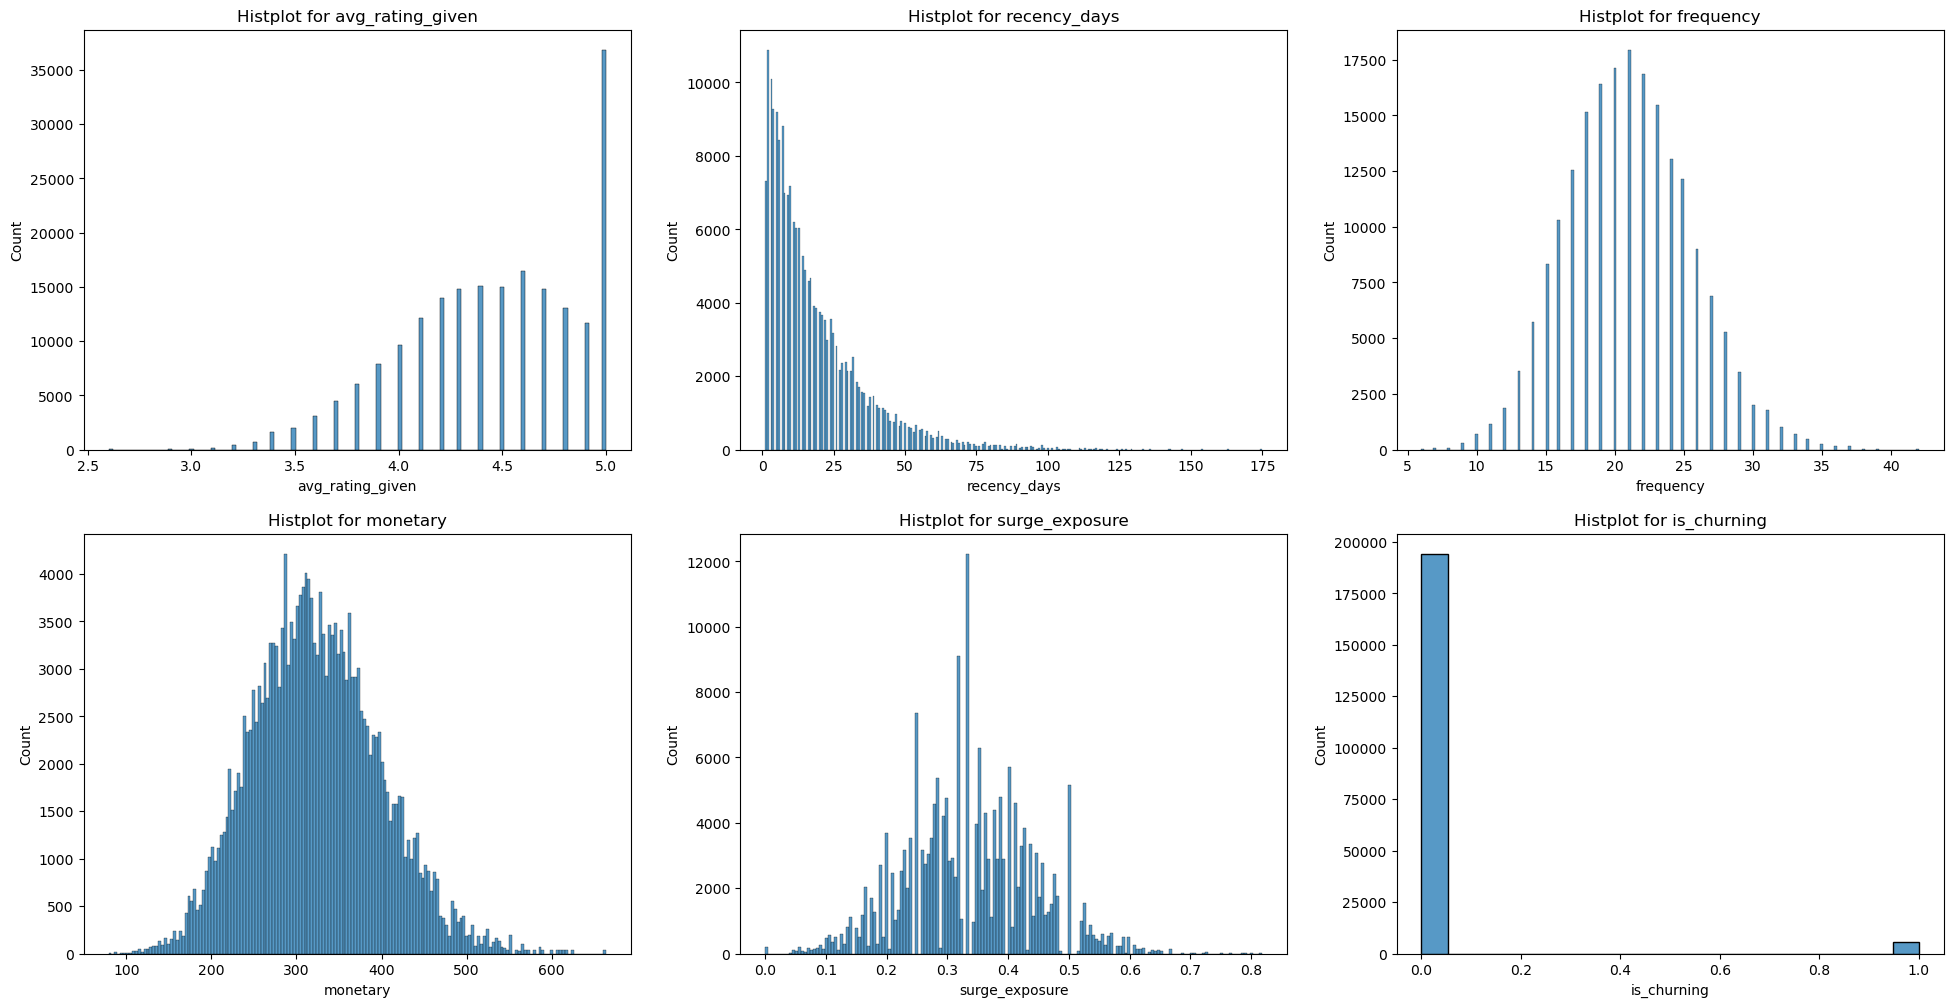

In [167]:
# Histplot for numerical columns

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(24,12))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns):
    sns.histplot(master_df[col], ax=ax[idx])
    ax[idx].set_title(f"Histplot for {col}")
plt.show()

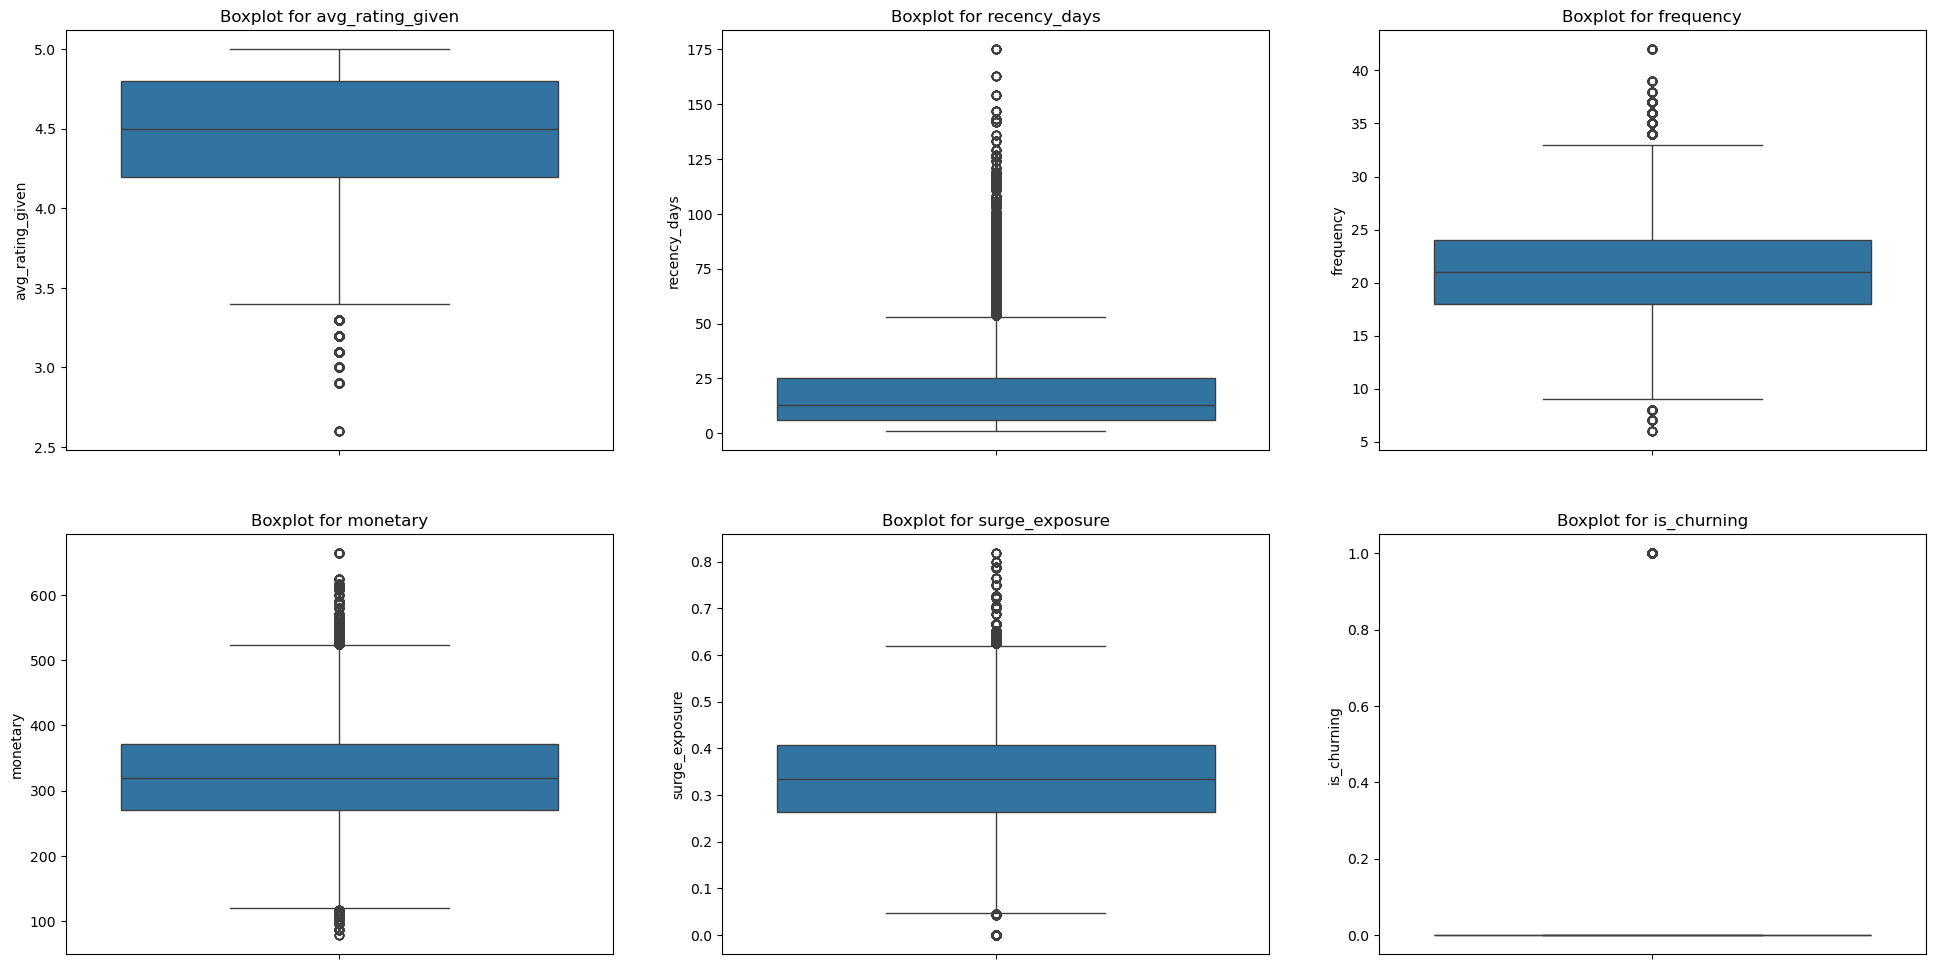

In [168]:
# Boxplot for numerical columns

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(24,12))
ax = ax.flatten()

for idx, col in enumerate(numerical_columns):
    sns.boxplot(master_df[col], ax=ax[idx])
    ax[idx].set_title(f"Boxplot for {col}")
plt.show()

***Insight:*** 
The outliers observed in the Recency (days) and Monetary variables were intentionally retained, as they likely represent meaningful customer behavior rather than data errors. These extreme values may signal high-value customers or customers exhibiting unusual engagement patterns, both of which are critical for accurately predicting churn. Removing them could reduce the model’s ability to identify at-risk segments and high-impact customer groups, ultimately weakening predictive performance and business insights.

In [170]:
# Separate the features from the target variable

X = master_df.drop("is_churning", axis=1)
y = master_df["is_churning"]

### Data Splitting

* The cleaned dataset will be split into training and testing sets, ensuring the target variable's distribution is representative in both
* Train and test data needs to be splitted before oversampling and scalling to prevent data leakage

In [172]:
from sklearn.model_selection import train_test_split

In [173]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Check Class Distribution
Access the balance of the target variable (is_churning) to determine if we need to handle class imbalance

In [175]:
master_df["is_churning"].value_counts()

is_churning
0    194276
1      5724
Name: count, dtype: int64

In [176]:
master_df["is_churning"].value_counts(normalize=True)*100

is_churning
0    97.138
1     2.862
Name: proportion, dtype: float64

<Axes: xlabel='is_churning', ylabel='count'>

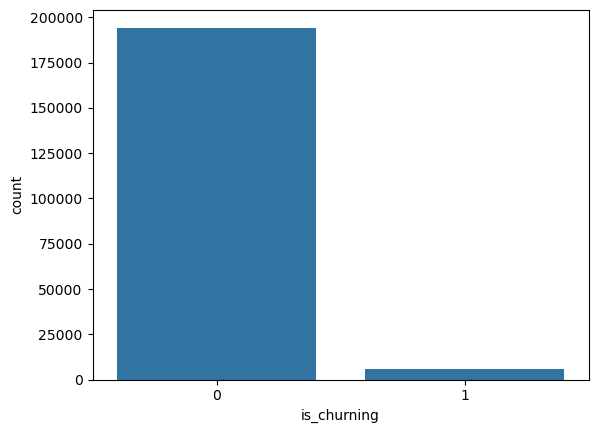

In [177]:
sns.countplot(x=master_df["is_churning"])

### Oversampling Technique with SMOTE to handle class imbalance

In [179]:
# Import SMOTE library

from imblearn.over_sampling import SMOTE

!pip install --upgrade imbalanced-learn

In [180]:
# Initialize SMOTE

smote = SMOTE(random_state=42)

In [181]:
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

<Axes: xlabel='is_churning', ylabel='count'>

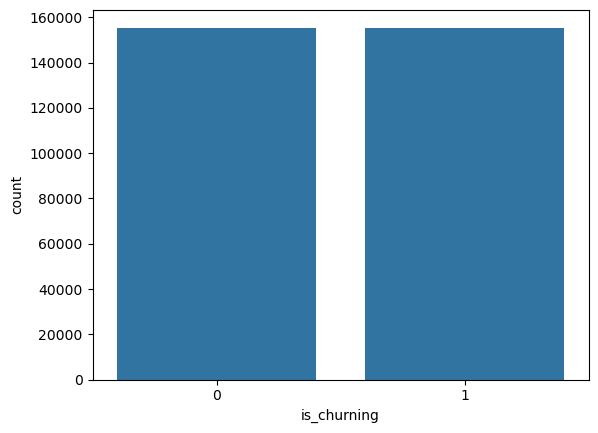

In [182]:
# Visualize the class distribution after SMOTE application

sns.countplot(x=y_train_res)

### Scale Numerical Features
* Scale numerical features to bring them to a similar range, which can improve model performance
* Standard scaler will be used because the data is slightly skewed

In [184]:
# import standard scaler library

from sklearn.preprocessing import StandardScaler

In [185]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

### Model Selection

Multiple classification models will be trained to find the best on for predicting rider's churn. Starting with a baseline model and expand to more advanced model.

#### 1. Train a Baseline Model(Logistic Regression)

In [187]:
from sklearn.linear_model import LogisticRegression

In [188]:
# Model Initialization

model = LogisticRegression(random_state=42, max_iter=1000)

In [189]:
# Model training

model.fit(X_train_scaled, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [190]:
# Predict on the test set
y_pred = model.predict(X_test_scaled)

In [191]:
from sklearn.metrics import classification_report, confusion_matrix

In [192]:
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

print("Logistic Regression Classification Report")
print(report)

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     38855
           1       0.15      0.92      0.26      1145

    accuracy                           0.85     40000
   macro avg       0.58      0.88      0.59     40000
weighted avg       0.97      0.85      0.90     40000



#### 2. Train Advanced Models

In [194]:
!pip install xgboost

In [195]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [196]:
# Models Initialization

models = {'Logistic Regression': LogisticRegression(random_state=42, class_weight="balanced"),
          'Random Forest': RandomForestClassifier(random_state=42, class_weight="balanced"),
          'Gradient Boosting': GradientBoostingClassifier(random_state=42),
          'Ada Boost': AdaBoostClassifier(random_state=42),
          'KNeighbors Classifier': KNeighborsClassifier(),
          'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight="balanced"),
          'XGBoost': XGBClassifier(eval_metric="mlogloss")
         }

Training Logistic Regression...
Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     38855
           1       0.15      0.92      0.26      1145

    accuracy                           0.85     40000
   macro avg       0.58      0.88      0.59     40000
weighted avg       0.97      0.85      0.90     40000



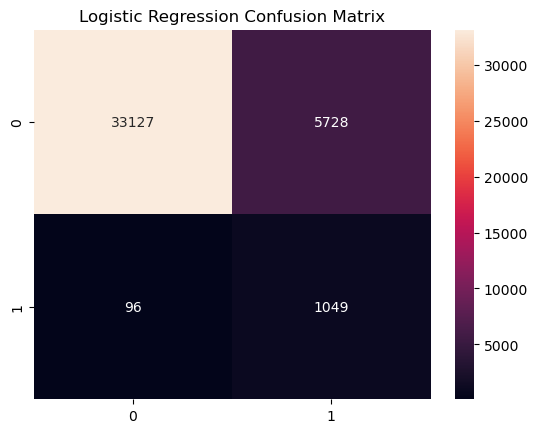

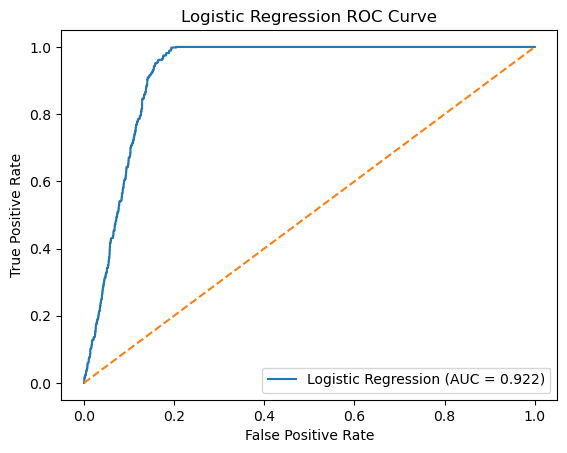

Training Random Forest...
Random Forest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38855
           1       1.00      1.00      1.00      1145

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



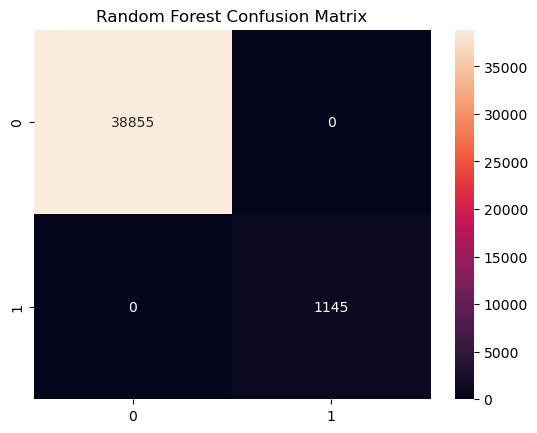

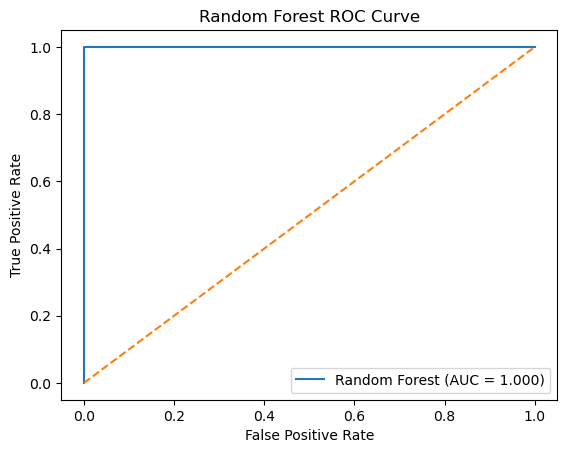

Training Gradient Boosting...
Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       1.00      0.85      0.92     38855
           1       0.17      1.00      0.29      1145

    accuracy                           0.86     40000
   macro avg       0.58      0.93      0.60     40000
weighted avg       0.98      0.86      0.90     40000



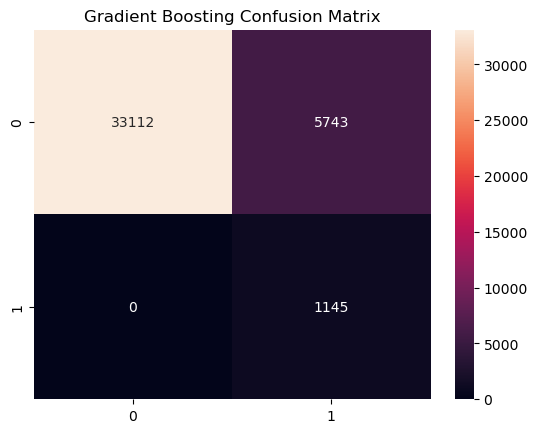

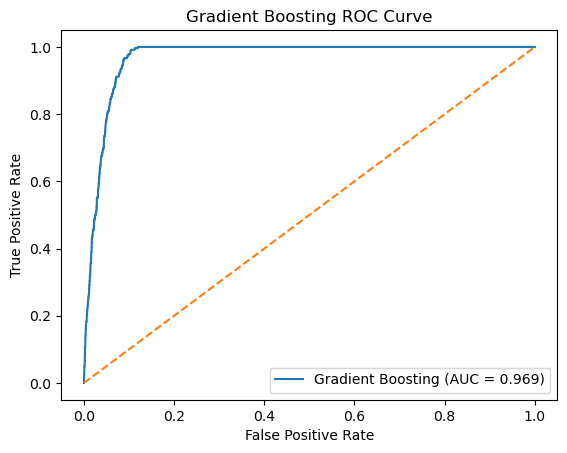

Training Ada Boost...
Ada Boost Classification Report
              precision    recall  f1-score   support

           0       1.00      0.84      0.91     38855
           1       0.16      1.00      0.27      1145

    accuracy                           0.85     40000
   macro avg       0.58      0.92      0.59     40000
weighted avg       0.98      0.85      0.90     40000



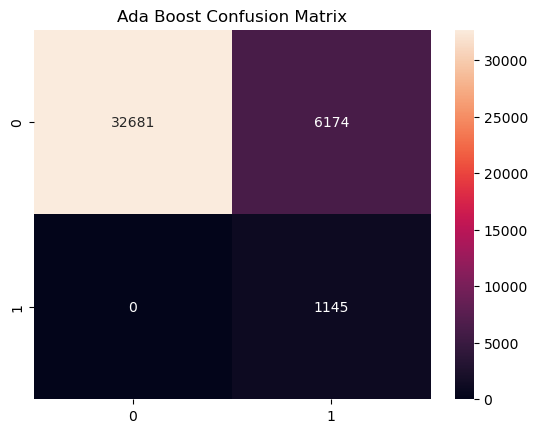

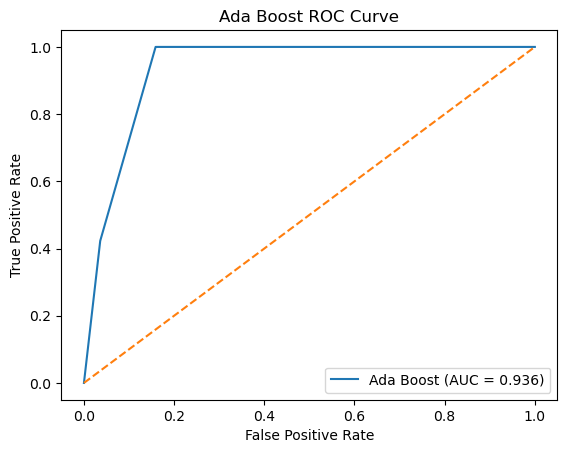

Training KNeighbors Classifier...
KNeighbors Classifier Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38855
           1       1.00      1.00      1.00      1145

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



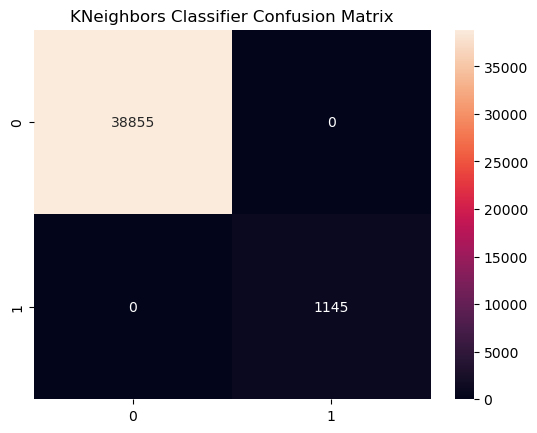

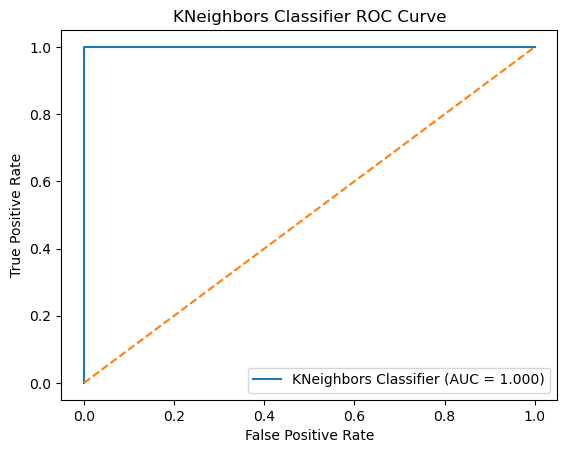

Training Decision Tree...
Decision Tree Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38855
           1       1.00      1.00      1.00      1145

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



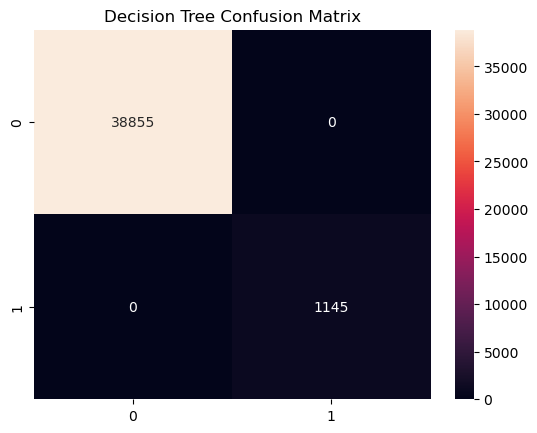

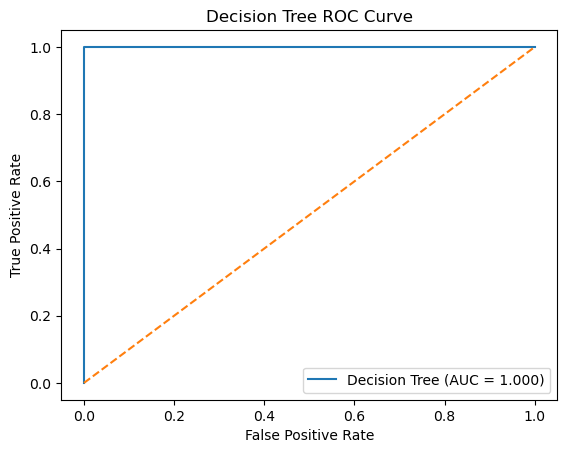

Training XGBoost...
XGBoost Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38855
           1       0.86      1.00      0.92      1145

    accuracy                           1.00     40000
   macro avg       0.93      1.00      0.96     40000
weighted avg       1.00      1.00      1.00     40000



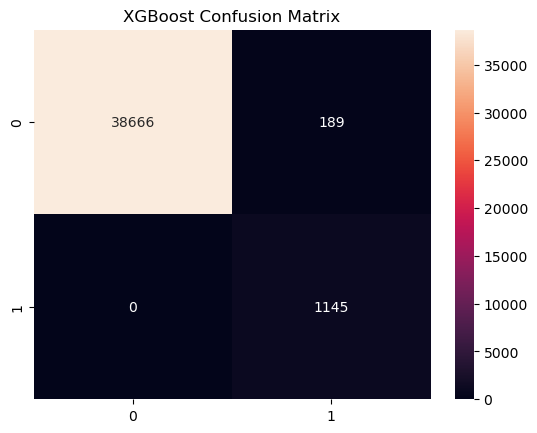

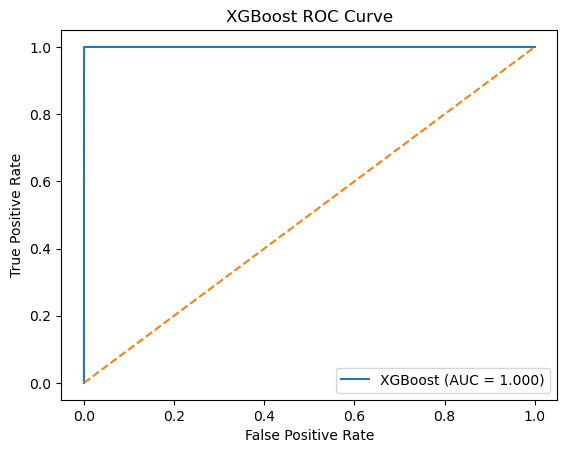

In [197]:
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    
    # Model Training
    model.fit(X_train_scaled, y_train_res)
    
    # Predict classes
    y_pred = model.predict(X_test_scaled)

    # Predict probabilities for ROC
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    matrix = confusion_matrix(y_test, y_pred)

    # ROC metrics
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'classification_report': report,
        'confusion_matrix': matrix,
        'roc_auc': roc_auc
    }

    print(f'{model_name} Classification Report')
    print(report)

    # Confusion Matrix
    sns.heatmap(matrix, annot=True, fmt='g')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    # ROC Curve
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} ROC Curve")
    plt.legend()
    plt.show()

In [198]:
rf_model = models["Random Forest"]

In [200]:
# Get importance values
importances = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

            Feature  Importance
1      recency_days    0.741886
3          monetary    0.091991
4    surge_exposure    0.063435
0  avg_rating_given    0.057714
2         frequency    0.044974


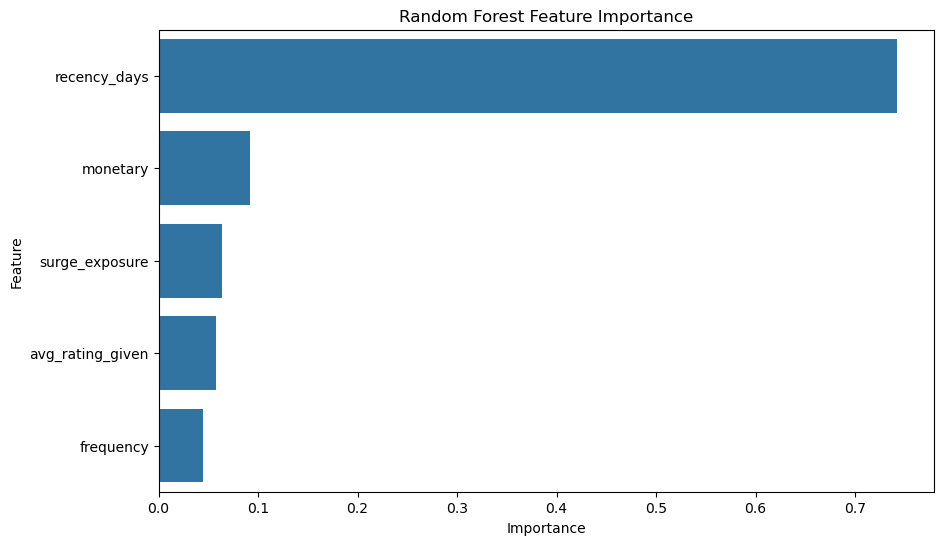

In [202]:
# Visualize feature importance
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Random Forest Feature Importance")
plt.show()

### Implementing SHAP Explainability feature on the best trained model (Random Forest)

100%|===================| 79937/80000 [13:38<00:00]        

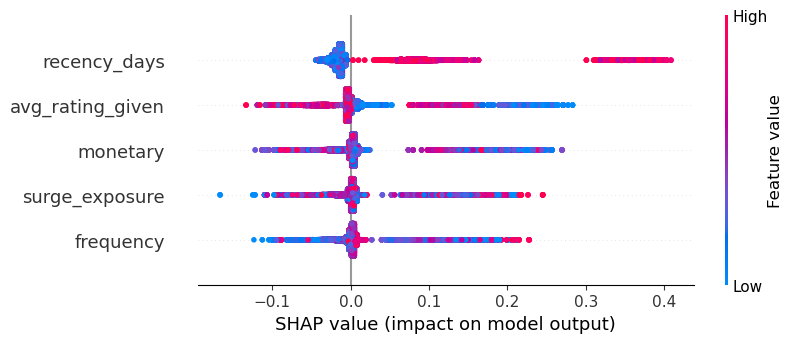

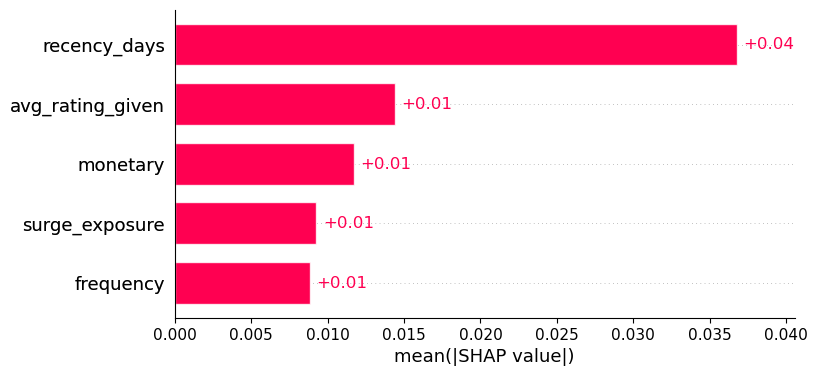

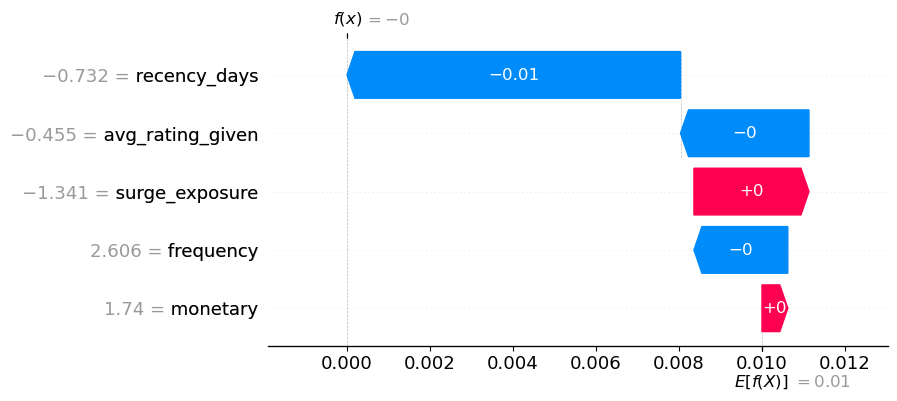

In [210]:
import shap


# DataFrame with feature names
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# Explainer
explainer = shap.Explainer(rf_model, X_test_scaled_df)

# SHAP values
shap_values = explainer(X_test_scaled_df)

# Global explanation for class 1
shap.plots.beeswarm(shap_values[:, :, 1])
shap.plots.bar(shap_values[:, :, 1])

# Local explanation for first test instance, class 1
shap.plots.waterfall(shap_values[0, :, 1])

### Save the Model

In [213]:
import joblib

joblib.dump(rf_model, r"C:\Users\pehlu\OneDrive\projects\RideWise\Model\random_forest_model.pkl")

print("Model saved successfully")

Model saved successfully
